# Algoritmos de optimización - Trabajo Práctico<br>
Nombre y Apellidos: David Carrasco Alonso  <br>
Url: https://github.com/david-ca/03MAIR---Algoritmos-de-Optimizacion/tree/main/TrabajoPractico<br>
Google Colab: https://colab.research.google.com/drive/1ds8sOxgSPgGh0Kc_GA-DIU2ZcmOdTGys <br>

Problema:
>1. Sesiones de doblaje <br>

**Descripción del problema:**

Se precisa coordinar el doblaje de una película. Los actores del doblaje deben coincidir en las tomas en las que sus personajes aparecen juntos en las diferentes tomas. Los actores de doblaje cobran todos la misma cantidad por cada día que deben desplazarse hasta el estudio de grabación independientemente del número de tomas que se graben. No es posible grabar más de 6 tomas por día. El objetivo es planificar las sesiones por día de manera que el gasto por los servicios de los actores de doblaje sea el menor posible.

- Número de actores: 10
- Número de tomas: 30
- Máximo de tomas por día: 6
- Los actores cobran igual por día, sin importar cuántas tomas graben ese día
- Objetivo: **Minimizar** el coste total (número total de días-actor)







                                        

# Nota sobre el uso de IA
En la elaboración de este trabajo se ha utilizado IA para ayudar con la codificación del algoritmo de recocido simulado aplicándolo a este problema de sesiones de doblaje.

# Modelo
- ¿Como represento el espacio de soluciones?
- ¿Cual es la función objetivo?
- ¿Como implemento las restricciones?

## Respuesta - Modelo

### Espacio de soluciones

Una solución es una **partición de las 30 tomas en grupos (días)**, donde cada grupo tiene como máximo 6 tomas. Representamos la solución como una lista de listas, donde cada sublista contiene los índices de las tomas asignadas a un día de grabación.

Ejemplo: `[[1,2,3,4,5,6], [7,8,9,10,11,12], ...]` significa que el día 1 se graban las tomas 1-6, el día 2 las tomas 7-12, etc.

### Función objetivo

Queremos **minimizar el coste total**, que es la suma del número de actores que deben asistir cada día.

$$f(S) = \sum_{d \in \text{días}} |\text{actores\_necesarios}(d)|$$

Para un día $d$ con tomas $T_d$, el conjunto de actores necesarios es la **unión** de los actores que participan en cada toma de ese día. Cada actor que participa en al menos una toma del día debe asistir (y cobra un día completo).

### Restricciones

1. **Máximo 6 tomas por día**: $|T_d| \leq 6, \quad \forall d$
2. **Todas las tomas deben ser grabadas**: $\bigcup_d T_d = \{1, 2, ..., 30\}$
3. **Cada toma se graba exactamente una vez**: $T_i \cap T_j = \emptyset, \quad \forall i \neq j$


In [2]:
import numpy as np
import random
import math


# DATOS DEL PROBLEMA

# Matriz de actores/tomas (30 tomas x 10 actores)
# 1 = el actor participa en la toma, 0 = no participa
# Filas: tomas (0-29), Columnas: actores (0-9)

datos = np.array([
    [1,1,1,1,1,0,0,0,0,0],  # Toma 1
    [0,0,1,1,1,0,0,0,0,0],  # Toma 2
    [0,1,0,0,1,0,1,0,0,0],  # Toma 3
    [1,1,0,0,0,0,1,1,0,0],  # Toma 4
    [0,1,0,1,0,0,0,1,0,0],  # Toma 5
    [1,1,0,1,1,0,0,0,0,0],  # Toma 6
    [1,1,0,1,1,0,0,0,0,0],  # Toma 7
    [1,1,0,0,0,1,0,0,0,0],  # Toma 8
    [1,1,0,1,0,0,0,0,0,0],  # Toma 9
    [1,0,0,0,0,1,0,0,1,0],  # Toma 10
    [1,0,1,0,1,0,0,1,0,0],  # Toma 11
    [1,1,1,1,0,1,0,0,0,0],  # Toma 12
    [1,0,0,1,1,0,0,0,0,0],  # Toma 13
    [1,0,0,1,0,0,1,0,0,0],  # Toma 14
    [1,0,1,0,0,0,1,0,0,0],  # Toma 15
    [0,0,0,1,0,0,0,0,0,1],  # Toma 16
    [1,0,1,0,0,0,0,0,0,0],  # Toma 17
    [0,0,1,0,0,1,0,0,0,0],  # Toma 18
    [1,0,1,0,0,0,0,0,0,0],  # Toma 19
    [1,0,1,1,1,0,0,0,0,0],  # Toma 20
    [0,0,0,0,0,1,0,1,0,0],  # Toma 21
    [1,1,1,1,0,0,0,0,0,0],  # Toma 22
    [1,0,1,0,0,0,0,0,0,0],  # Toma 23
    [0,0,1,0,0,1,0,0,0,0],  # Toma 24
    [1,1,0,1,0,0,0,0,0,1],  # Toma 25
    [1,0,1,0,1,0,0,0,1,0],  # Toma 26
    [0,0,0,1,1,0,0,0,0,0],  # Toma 27
    [1,0,0,0,1,0,0,0,0,0],  # Toma 28
    [1,0,0,0,0,1,1,0,0,0],  # Toma 29
    [1,0,0,0,1,0,0,0,0,0],  # Toma 30
])

num_tomas = 30
num_actores = 10
MAX_TOMAS_DIA = 6

print(f"Número de tomas: {num_tomas}")
print(f"Número de actores: {num_actores}")
print(f"Máximo tomas por día: {MAX_TOMAS_DIA}")

Número de tomas: 30
Número de actores: 10
Máximo tomas por día: 6


In [3]:
# FUNCIÓN OBJETIVO: calcular el coste de una solución


def calcular_actores_dia(tomas_dia, datos):
    """
    Dado un conjunto de tomas para un día, devuelve el número de actores
    que deben asistir ese día.
    """
    if len(tomas_dia) == 0:
        return 0
    # Unión de actores: si al menos una toma del día requiere al actor, debe venir
    actores_necesarios = np.max(datos[tomas_dia], axis=0)
    return int(np.sum(actores_necesarios))


def calcular_coste_total(solucion, datos):
    """
    Calcula el coste total de una solución (partición de tomas en días).
    El coste es la suma de actores que asisten cada día.
    """
    coste = 0
    for dia in solucion:
        coste += calcular_actores_dia(dia, datos)
    return coste


# Ejemplo: si todas las tomas van de 6 en 6 en orden
solucion_naive = [[0,1,2,3,4,5], [6,7,8,9,10,11], [12,13,14,15,16,17], [18,19,20,21,22,23], [24,25,26,27,28,29]]
print("Solución naive (tomas en orden de 6 en 6):")
for i, dia in enumerate(solucion_naive):
    actores = calcular_actores_dia(dia, datos)
    tomas_mostrar = [t+1 for t in dia]
    print(f"  Día {i+1}: Tomas {tomas_mostrar} -> {actores} actores")
print(f"Coste total naive: {calcular_coste_total(solucion_naive, datos)}")




Solución naive (tomas en orden de 6 en 6):
  Día 1: Tomas [1, 2, 3, 4, 5, 6] -> 7 actores
  Día 2: Tomas [7, 8, 9, 10, 11, 12] -> 8 actores
  Día 3: Tomas [13, 14, 15, 16, 17, 18] -> 7 actores
  Día 4: Tomas [19, 20, 21, 22, 23, 24] -> 7 actores
  Día 5: Tomas [25, 26, 27, 28, 29, 30] -> 9 actores
Coste total naive: 38


#Análisis
- ¿Que complejidad tiene el problema?. Orden de complejidad y Contabilizar el espacio de soluciones

## Respuesta - Análisis

### Tipo de problema

Este es un problema de **optimización combinatoria**.

### Espacio de soluciones

Con 30 tomas y grupos de exactamente 6, el mínimo de días necesarios es $\lceil 30/6 \rceil = 5$ días.

El número de formas de repartir 30 tomas en 5 grupos de 6 es:

$$\frac{\binom{30}{6} \cdot \binom{24}{6} \cdot \binom{18}{6} \cdot \binom{12}{6} \cdot \binom{6}{6}}{5!} = \frac{593,775 \times 134,596 \times 18,564 \times 924 \times 1}{120} \approx 1.14 \times 10^{16}$$

Es un espacio muy grande, lo que hace inviable la fuerza bruta.

Si además consideramos soluciones con diferente número de días (ej: 6 días con algunos días con menos de 6 tomas), el espacio es aún mayor.

<br>

**El razonamiento:**
Es un problema de combinación sin repetición. Utilizando esta tabla de los apuntes de clase de la asignatura de Matemáticas para la Inteligencia Articial:

<br>

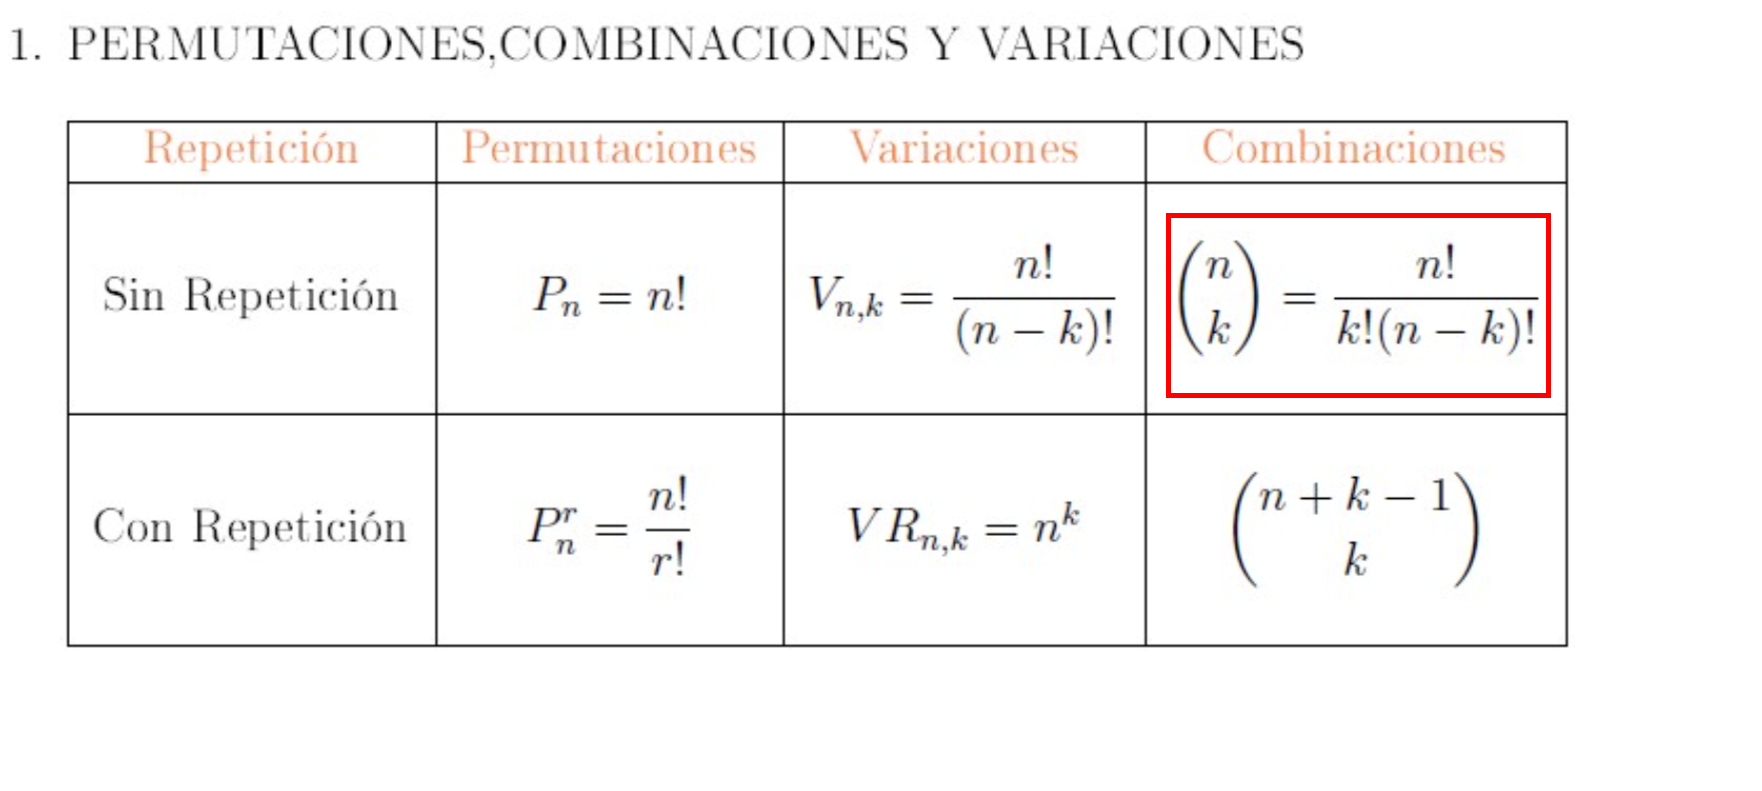
Para el día 1, eliges 6 tomas de las 30 disponibles. ¿De cuántas formas? C(30,6) = 593,775 formas.

Para el día 2, quedan 24 tomas y eliges 6. C(24,6) = 134,596 formas.

Para el día 3, quedan 18. C(18,6) = 18,564 formas.

Para el día 4, quedan 12. C(12,6) = 924 formas.

Para el día 5, quedan 6 y las coges todas. C(6,6) = 1 forma.

Si multiplicas todo eso, obtienes todas las formas posibles. Por otro lado, el orden de los días no importa. Que el día 1 tenga las tomas {1,2,3,4,5,6} y el día 2 tenga {7,8,9,10,11,12} es lo mismo que al revés. Hay 5! = 120 formas de ordenar 5 días, así que dividimos entre 120 para no contar repetidos.
El resultado es ~1.14 × 10¹⁶, o sea más de 11 mil billones de combinaciones posibles.

<br>

**Orden de complejidad**

La complejidad es O(exponencial), porque el número de combinaciones crece exponencialmente con n. Para nuestro caso concreto:

- Con n=30 tomas: ~10¹⁶ combinaciones.

- Si tuviéramos n=60 tomas: el número se dispararía muchísimo más.


In [4]:
# Verificación del tamaño del espacio de soluciones
from math import comb, factorial

# Número de particiones de 30 elementos en 5 grupos de 6 (sin orden entre grupos)
numerador = comb(30,6) * comb(24,6) * comb(18,6) * comb(12,6) * comb(6,6)
denominador = factorial(5)  # Los días no tienen orden intrínseco
particiones = numerador // denominador

print(f"Particiones de 30 tomas en 5 grupos de 6: {particiones:,.0f}")
print(f"En notación científica: {particiones:.2e}")
print()
print("Esto confirma que la fuerza bruta es INVIABLE.")
print("Se necesita una heurística para encontrar una buena solución.")

Particiones de 30 tomas en 5 grupos de 6: 11,423,951,396,577,720
En notación científica: 1.14e+16

Esto confirma que la fuerza bruta es INVIABLE.
Se necesita una heurística para encontrar una buena solución.


#Diseño
- ¿Que técnica utilizo? ¿Por qué?

## Respuesta - Diseño

### Técnica: Recocido Simulado (Simulated Annealing)

Utilizo **recocido simulado** porque:

1. **Escapa de óptimos locales**: A diferencia de un algoritmo voraz, el recocido simulado puede aceptar soluciones peores temporalmente, lo que le permite explorar más el espacio de soluciones y evitar quedarse atrapado en un mínimo local.
2. **Buena calidad de solución**: Para problemas combinatorios como este, el recocido simulado produce soluciones cercanas al óptimo.
3. **Simplicidad de implementación**: Solo necesitamos definir una solución inicial, un vecindario (cómo generar soluciones vecinas) y un esquema de enfriamiento.

### ¿Cómo funciona el recocido simulado?

El algoritmo se inspira en el proceso de enfriamiento de metales:

1. **Solución inicial**: Partimos de una solución generada con un algoritmo voraz.
2. **Generación de vecinos**: En cada iteración, generamos una solución vecina **intercambiando dos tomas entre dos días distintos**.
3. **Criterio de aceptación**:
   - Si el vecino es **mejor** (menor coste), se acepta siempre.
   - Si el vecino es **peor**, se acepta con probabilidad $e^{-\Delta / T}$, donde $\Delta$ es el incremento de coste y $T$ es la temperatura actual.
4. **Enfriamiento**: La temperatura $T$ va disminuyendo gradualmente según $T_{nueva} = \alpha \cdot T$, donde $\alpha$ es un factor cercano a 1.

Al principio, con $T$ alta, se aceptan muchas soluciones peores. Al final, con $T$ baja, solo se aceptan mejoras.

### Parámetros elegidos

- **Temperatura inicial** ($T_0$): 8.0
- **Temperatura final** ($T_f$): 0.001
- **Iteraciones**: 1,000,000
- **Factor de enfriamiento** ($\alpha$): se calcula como $(T_f / T_0)^{1/\text{iteraciones}}$

### ¿Por qué esta técnica y no otra?

- Un **algoritmo voraz** es rápido pero se queda en un mínimo local (coste 32 en este caso).
- El recocido simulado, al permitir empeoramientos temporales, logra escapar de ese mínimo y alcanzar soluciones de coste **27**, una mejora significativa.


### Pseudocódigo del Recocido Simulado
```
RECOCIDO SIMULADO

Entrada: datos de tomas/actores, T₀, Tf, número de iteraciones
Salida: mejor solución encontrada

1.  Generar solución inicial con algoritmo voraz
2.  mejor_solución ← solución actual
3.  mejor_coste ← coste de la solución actual
4.  T ← T₀
5.  α ← (Tf / T₀) ^ (1 / iteraciones)

6.  REPETIR iteraciones veces:
7.      Elegir dos días distintos al azar: día_A, día_B
8.      Elegir una toma al azar de día_A: toma_1
9.      Elegir una toma al azar de día_B: toma_2
10.     Intercambiar toma_1 y toma_2 → solución vecina
11.     delta ← coste(vecino) - coste(actual)
12.     SI delta < 0 ENTONCES
13.         Aceptar vecino (es mejor)
14.     SI NO
15.         Generar número aleatorio r entre 0 y 1
16.         SI r < e^(-delta / T) ENTONCES
17.             Aceptar vecino (es peor, pero se acepta con cierta probabilidad)
18.     SI coste(actual) < mejor_coste ENTONCES
19.         mejor_solución ← solución actual
20.         mejor_coste ← coste(actual)
21.     T ← T × α  (enfriar)

22. DEVOLVER mejor_solución, mejor_coste
```

In [5]:
# ALGORITMO VORAZ (solución inicial para Recocido Simulado)

def algoritmo_voraz(datos, max_tomas_dia):
    """
    Genera una solución inicial usando un algoritmo voraz.
    Estrategia: empezar por la toma con menos actores y añadir
    la toma que menor incremento de actores nuevos suponga.
    """
    num_tomas = 30
    tomas_restantes = set(range(num_tomas))
    solucion = []

    while tomas_restantes:
        dia_actual = []
        actores_dia = np.zeros(datos.shape[1])

        # Paso 1: Elegir toma semilla - la que tiene menos actores
        mejor_toma = None
        min_actores = float('inf')
        for t in tomas_restantes:
            n_actores = int(np.sum(datos[t]))
            if n_actores < min_actores:
                min_actores = n_actores
                mejor_toma = t

        dia_actual.append(mejor_toma)
        actores_dia = np.maximum(actores_dia, datos[mejor_toma])
        tomas_restantes.remove(mejor_toma)

        # Paso 2: Añadir tomas al día (hasta max_tomas_dia)
        while len(dia_actual) < max_tomas_dia and tomas_restantes:
            mejor_toma = None
            min_incremento = float('inf')

            for t in tomas_restantes:
                actores_nuevos = np.maximum(actores_dia, datos[t])
                incremento = int(np.sum(actores_nuevos)) - int(np.sum(actores_dia))

                if incremento < min_incremento:
                    min_incremento = incremento
                    mejor_toma = t

            dia_actual.append(mejor_toma)
            actores_dia = np.maximum(actores_dia, datos[mejor_toma])
            tomas_restantes.remove(mejor_toma)

        solucion.append(dia_actual)

    return solucion


# Generar solución inicial
solucion_inicial = algoritmo_voraz(datos, MAX_TOMAS_DIA)
coste_inicial = calcular_coste_total(solucion_inicial, datos)

print("Solución inicial (voraz):")
for i, dia in enumerate(solucion_inicial):
    actores = calcular_actores_dia(dia, datos)
    tomas_mostrar = sorted([t+1 for t in dia])
    print(f"  Día {i+1}: Tomas {tomas_mostrar} -> {actores} actores")
print(f"Coste inicial: {coste_inicial}")

Solución inicial (voraz):
  Día 1: Tomas [2, 13, 16, 17, 19, 27] -> 5 actores
  Día 2: Tomas [4, 8, 18, 21, 23, 24] -> 6 actores
  Día 3: Tomas [3, 6, 7, 9, 28, 30] -> 5 actores
  Día 4: Tomas [1, 5, 11, 14, 15, 22] -> 7 actores
  Día 5: Tomas [10, 12, 20, 25, 26, 29] -> 9 actores
Coste inicial: 32


In [6]:
# RECOCIDO SIMULADO (Simulated Annealing)

def recocido_simulado(datos, max_tomas_dia, T_inicio=8.0, T_final=0.001, iteraciones=1000000, semilla=3):
    """
    Recocido simulado para minimizar el coste de sesiones de doblaje.

    Parámetros:
    - T_inicio: temperatura inicial (alta = más exploración)
    - T_final: temperatura final (baja = solo mejoras)
    - iteraciones: número de pasos del algoritmo
    - semilla: semilla aleatoria para reproducibilidad
    """
    random.seed(semilla)

    # Paso 1: Solución inicial con algoritmo voraz
    solucion_actual = algoritmo_voraz(datos, max_tomas_dia)
    coste_actual = calcular_coste_total(solucion_actual, datos)

    # Mejor solución encontrada
    mejor_solucion = [list(d) for d in solucion_actual]
    mejor_coste = coste_actual

    # Factor de enfriamiento
    alpha = (T_final / T_inicio) ** (1.0 / iteraciones)
    T = T_inicio

    # Registro de evolución
    historial = []

    for it in range(iteraciones):
        # Paso 2: Generar vecino (intercambiar dos tomas entre dos días)
        d1, d2 = random.sample(range(len(solucion_actual)), 2)

        if not solucion_actual[d1] or not solucion_actual[d2]:
            T *= alpha
            continue

        t1 = random.choice(solucion_actual[d1])
        t2 = random.choice(solucion_actual[d2])

        # Crear solución vecina
        vecino = [list(d) for d in solucion_actual]
        vecino[d1].remove(t1)
        vecino[d1].append(t2)
        vecino[d2].remove(t2)
        vecino[d2].append(t1)

        coste_vecino = calcular_coste_total(vecino, datos)

        # Paso 3: Criterio de aceptación de Metropolis
        delta = coste_vecino - coste_actual

        if delta < 0 or random.random() < math.exp(-delta / max(T, 1e-10)):
            solucion_actual = vecino
            coste_actual = coste_vecino

            if coste_actual < mejor_coste:
                mejor_coste = coste_actual
                mejor_solucion = [list(d) for d in solucion_actual]

        # Paso 4: Enfriar
        T *= alpha

        # Guardar historial cada 10000 iteraciones
        if it % 10000 == 0:
            historial.append((it, coste_actual, mejor_coste, T))

    return mejor_solucion, mejor_coste, historial


# Ejecutar
print("Ejecutando Recocido Simulado...")
print("(esto puede tardar unos segundos)\n")

solucion_sa, coste_sa, historial = recocido_simulado(
    datos, MAX_TOMAS_DIA,
    T_inicio=8.0,
    T_final=0.001,
    iteraciones=1000000,
    semilla=3
)

print(f"Coste final: {coste_sa}")

Ejecutando Recocido Simulado...
(esto puede tardar unos segundos)

Coste final: 27


In [7]:
# MEJOR SOLUCIÓN ENCONTRADA

print("=" * 60)
print("MEJOR SOLUCIÓN - RECOCIDO SIMULADO")
print("=" * 60)

coste_total = 0
for i, dia in enumerate(solucion_sa):
    actores_necesarios = np.max(datos[dia], axis=0)
    n_actores = int(np.sum(actores_necesarios))
    coste_total += n_actores
    tomas_mostrar = sorted([t+1 for t in dia])
    actores_lista = [j+1 for j in range(num_actores) if actores_necesarios[j] == 1]

    print(f"\nDía {i+1}:")
    print(f"  Tomas grabadas: {tomas_mostrar}")
    print(f"  Actores convocados: {actores_lista} ({n_actores} actores)")

print(f"\n{'=' * 60}")
print(f"COSTE TOTAL: {coste_total} días-actor")
print(f"Días de grabación: {len(solucion_sa)}")
print(f"{'=' * 60}")

MEJOR SOLUCIÓN - RECOCIDO SIMULADO

Día 1:
  Tomas grabadas: [8, 12, 16, 18, 22, 25]
  Actores convocados: [1, 2, 3, 4, 6, 10] (6 actores)

Día 2:
  Tomas grabadas: [3, 4, 5, 6, 9, 14]
  Actores convocados: [1, 2, 4, 5, 7, 8] (6 actores)

Día 3:
  Tomas grabadas: [15, 17, 19, 23, 24, 29]
  Actores convocados: [1, 3, 6, 7] (4 actores)

Día 4:
  Tomas grabadas: [10, 11, 21, 26, 28, 30]
  Actores convocados: [1, 3, 5, 6, 8, 9] (6 actores)

Día 5:
  Tomas grabadas: [1, 2, 7, 13, 20, 27]
  Actores convocados: [1, 2, 3, 4, 5] (5 actores)

COSTE TOTAL: 27 días-actor
Días de grabación: 5


In [8]:
# COMPARACIÓN DE RESULTADOS

coste_naive = calcular_coste_total(solucion_naive, datos)
coste_greedy = calcular_coste_total(solucion_inicial, datos)

print("Comparación de técnicas:\n")
print(f"  Solución naive (orden secuencial):   {coste_naive} días-actor")
print(f"  Algoritmo voraz (greedy):             {coste_greedy} días-actor")
print(f"  Recocido simulado (SA):               {coste_sa} días-actor")

mejora_vs_naive = ((coste_naive - coste_sa) / coste_naive) * 100
mejora_vs_greedy = ((coste_greedy - coste_sa) / coste_greedy) * 100

print(f"\nMejora del SA vs naive:  {mejora_vs_naive:.1f}%")
print(f"Mejora del SA vs voraz:  {mejora_vs_greedy:.1f}%")
print(f"\nEl recocido simulado mejora significativamente respecto al voraz")
print(f"porque es capaz de escapar del mínimo local en el que se queda el greedy.")

Comparación de técnicas:

  Solución naive (orden secuencial):   38 días-actor
  Algoritmo voraz (greedy):             32 días-actor
  Recocido simulado (SA):               27 días-actor

Mejora del SA vs naive:  28.9%
Mejora del SA vs voraz:  15.6%

El recocido simulado mejora significativamente respecto al voraz
porque es capaz de escapar del mínimo local en el que se queda el greedy.


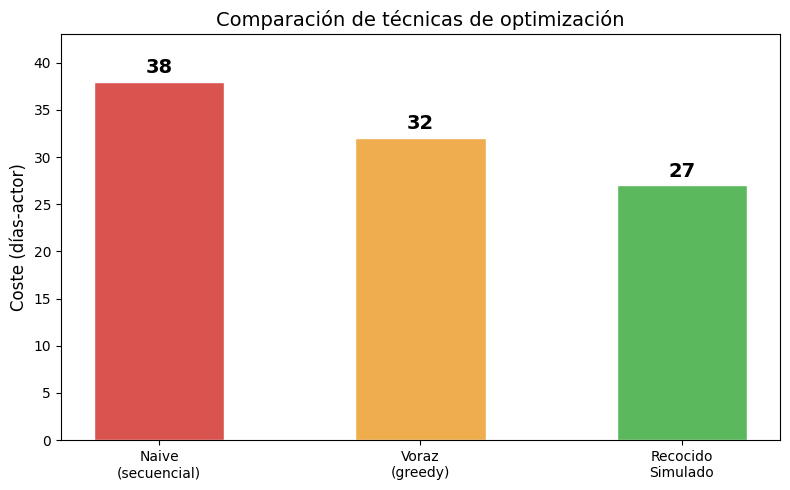

In [10]:
# GRÁFICO COMPARATIVO

import matplotlib.pyplot as plt

tecnicas = ['Naive\n(secuencial)', 'Voraz\n(greedy)', 'Recocido\nSimulado']
costes = [coste_naive, coste_greedy, coste_sa]
colores = ['#d9534f', '#f0ad4e', '#5cb85c']

fig, ax = plt.subplots(figsize=(8, 5))
barras = ax.bar(tecnicas, costes, color=colores, width=0.5, edgecolor='white')

# Poner el valor encima de cada barra
for barra, coste in zip(barras, costes):
    ax.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 0.5,
            str(coste), ha='center', va='bottom', fontsize=14, fontweight='bold')

ax.set_ylabel('Coste (días-actor)', fontsize=12)
ax.set_title('Comparación de técnicas de optimización', fontsize=14)
ax.set_ylim(0, max(costes) + 5)

plt.tight_layout()
plt.show()

In [12]:
# EVOLUCIÓN DEL RECOCIDO SIMULADO

print("Evolución del algoritmo (cada 100,000 iteraciones):\n")
print(f"{'Iteración':>12} | {'Coste actual':>14} | {'Mejor coste':>13} | {'Temperatura':>13}")
print("-" * 62)

for it, coste_act, mejor, temp in historial:
    if it % 100000 == 0:
        print(f"{it:>12,} | {coste_act:>14} | {mejor:>13} | {temp:>13.4f}")

print(f"\nSe observa cómo la temperatura va bajando y el algoritmo")
print(f"converge hacia la mejor solución encontrada.")

Evolución del algoritmo (cada 100,000 iteraciones):

   Iteración |   Coste actual |   Mejor coste |   Temperatura
--------------------------------------------------------------
           0 |             34 |            32 |        7.9999
     100,000 |             37 |            32 |        3.2567
     200,000 |             38 |            30 |        1.3258
     300,000 |             35 |            29 |        0.5397
     400,000 |             30 |            27 |        0.2197
     500,000 |             27 |            27 |        0.0894
     600,000 |             27 |            27 |        0.0364
     700,000 |             27 |            27 |        0.0148
     800,000 |             27 |            27 |        0.0060
     900,000 |             27 |            27 |        0.0025

Se observa cómo la temperatura va bajando y el algoritmo
converge hacia la mejor solución encontrada.


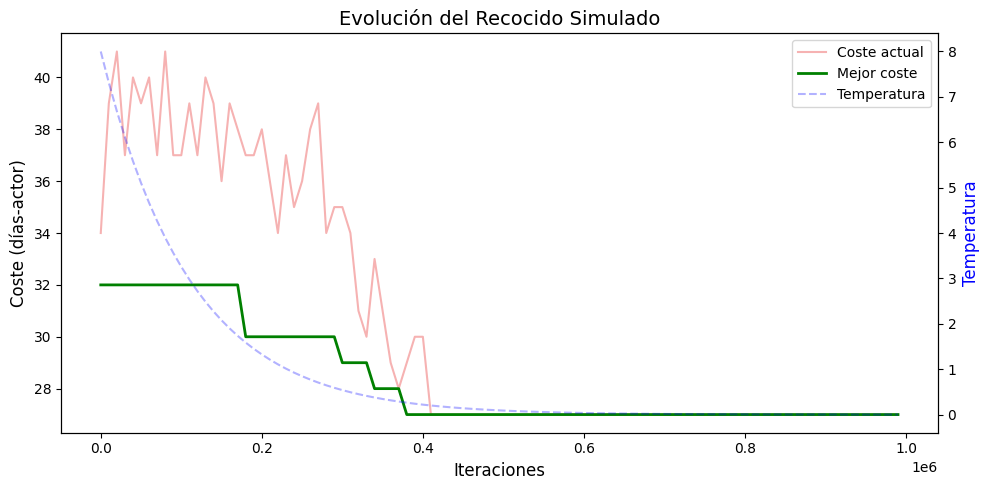

In [11]:
# GRÁFICO DE EVOLUCIÓN DEL RECOCIDO SIMULADO

import matplotlib.pyplot as plt

iteraciones_hist = [h[0] for h in historial]
costes_actuales = [h[1] for h in historial]
mejores_costes = [h[2] for h in historial]
temperaturas = [h[3] for h in historial]

fig, ax1 = plt.subplots(figsize=(10, 5))

# Eje izquierdo: costes
ax1.plot(iteraciones_hist, costes_actuales, color='lightcoral', alpha=0.6, label='Coste actual')
ax1.plot(iteraciones_hist, mejores_costes, color='green', linewidth=2, label='Mejor coste')
ax1.set_xlabel('Iteraciones', fontsize=12)
ax1.set_ylabel('Coste (días-actor)', fontsize=12)

# Eje derecho: temperatura
ax2 = ax1.twinx()
ax2.plot(iteraciones_hist, temperaturas, color='blue', alpha=0.3, linestyle='--', label='Temperatura')
ax2.set_ylabel('Temperatura', fontsize=12, color='blue')

# Leyenda combinada
lineas1, etiquetas1 = ax1.get_legend_handles_labels()
lineas2, etiquetas2 = ax2.get_legend_handles_labels()
ax1.legend(lineas1 + lineas2, etiquetas1 + etiquetas2, loc='upper right')

ax1.set_title('Evolución del Recocido Simulado', fontsize=14)
plt.tight_layout()
plt.show()

In [9]:
# TABLA DE PARTICIPACIÓN DE ACTORES POR DÍA

print("Participación de actores por día de grabación:\n")

header = f"{'Día':>4} | "
for a in range(1, num_actores + 1):
    header += f"Act{a:>2} "
header += "| Total"
print(header)
print("-" * len(header))

total_por_actor = np.zeros(num_actores)

for i, dia in enumerate(solucion_sa):
    actores_dia = np.max(datos[dia], axis=0)
    total_por_actor += actores_dia
    row = f"{i+1:>4} | "
    for a in range(num_actores):
        simbolo = 'X' if actores_dia[a] else '.'
        row += f"  {simbolo}   "
    row += f"|   {int(np.sum(actores_dia))}"
    print(row)

print("-" * len(header))
row = f"{'Tot':>4} | "
for a in range(num_actores):
    row += f"  {int(total_por_actor[a])}   "
row += f"|  {int(np.sum(total_por_actor))}"
print(row)
print(f"\nCoste total = {int(np.sum(total_por_actor))} días-actor")

Participación de actores por día de grabación:

 Día | Act 1 Act 2 Act 3 Act 4 Act 5 Act 6 Act 7 Act 8 Act 9 Act10 | Total
--------------------------------------------------------------------------
   1 |   X     X     X     X     .     X     .     .     .     X   |   6
   2 |   X     X     .     X     X     .     X     X     .     .   |   6
   3 |   X     .     X     .     .     X     X     .     .     .   |   4
   4 |   X     .     X     .     X     X     .     X     X     .   |   6
   5 |   X     X     X     X     X     .     .     .     .     .   |   5
--------------------------------------------------------------------------
 Tot |   5     3     4     3     3     3     2     2     1     1   |  27

Coste total = 27 días-actor
